In [400]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [401]:
az.style.use("arviz-whitegrid")
plt.rcParams["figure.figsize"] = [12, 5]
%config InlineBackend.figure_format = 'retina'

In [402]:
salaries = pd.read_csv("../data-download/data/j1l_salaries.csv")
salaries.head()

,name_player,annual_salary,position,age
0,Andrés Iniesta,27901500,MF,41
1,Yuya Osako,2450561,FW,35
2,Kasper Junker,1400320,FW,31
3,Mateus,1295296,FW,30
4,Gōtoku Sakai,1260288,DF,34


In [472]:
complete_data = pd.read_csv("../data-download/data/j1l_transformed_small.csv")

complete_data["goal"] = complete_data["goal"].astype(int)
complete_data["goals_in_match"] = complete_data["goals_in_match"].astype(int)

complete_data["kick_off"] = pd.to_datetime(
    complete_data["kick_off"], yearfirst=True
).dt.normalize()

# compute season number for each player, ~maturity of player
complete_data["season_nbr"] = complete_data.groupby(["name_player"])[
    "season"
].transform(lambda x: x.factorize(sort=True)[0])

complete_data = complete_data.sort_values(["name_player", "kick_off"]).reset_index(
    drop=True
)

In [473]:
mindex_coords_original = xr.Coordinates.from_pandas_multiindex(
    complete_data.set_index(["name_player", "season", "gameday"]).index,
    "obs_id",
)

In [474]:
ELITE_LEVEL = pd.read_csv("../data-download/data/j1l_elite_players.csv").player.values

In [475]:
REPLACEMENT_LEVEL = pd.read_csv("../data-download/data/j1l_replacement_players.csv").player.values

In [476]:
post_preds = az.from_netcdf("idata_complete_final_post_preds.nc").posterior

In [477]:
rlp_perf = post_preds["goals_scored"].where(
    post_preds["name_player"].isin(REPLACEMENT_LEVEL), drop=True
)
elite_perf = post_preds["goals_scored"].where(
    post_preds["name_player"].isin(ELITE_LEVEL), drop=True
)
PAR = (
    elite_perf.groupby("name_player").mean("obs_id") - rlp_perf.mean("obs_id")
).rename("PAR")

In [478]:
counterfact_preds = az.from_netcdf("idata_complete_final_counterfact_preds.nc")

In [479]:
counterfact_preds.predictions = counterfact_preds.predictions.assign_coords(
    mindex_coords_original
)

preds = counterfact_preds.predictions["goals_scored"].reset_index("obs_id")
rlp_perf = preds.where(preds["name_player"].isin(REPLACEMENT_LEVEL), drop=True)
elite_perf = preds.where(preds["name_player"].isin(ELITE_LEVEL), drop=True)

SAR = (
    elite_perf.groupby("name_player").mean("obs_id") - rlp_perf.mean("obs_id")
).rename("SAR")
diff = SAR - PAR

In [480]:
PLAYER_SUBSET = ELITE_LEVEL
SAR_plot = SAR.where(SAR["name_player"].isin(PLAYER_SUBSET), drop=True).rename("")
diff_plot = diff.where(diff["name_player"].isin(PLAYER_SUBSET), drop=True).rename("")

SAR_mean = SAR_plot.mean(("chain", "draw"))

# sort indices based on means in descending order
sorted_indices = np.argsort(-SAR_mean.to_numpy())

# reorder based on sorted indices
sorted_SAR_plot = SAR_plot.isel(name_player=sorted_indices[:15])
sorted_SAR_plot["name_player"] = sorted_SAR_plot.name_player.str.replace(
    "-", " "
).str.title()
sorted_diff_plot = diff_plot.isel(name_player=sorted_indices[:15])
sorted_diff_plot["name_player"] = sorted_diff_plot.name_player.str.replace(
    "-", " "
).str.title()

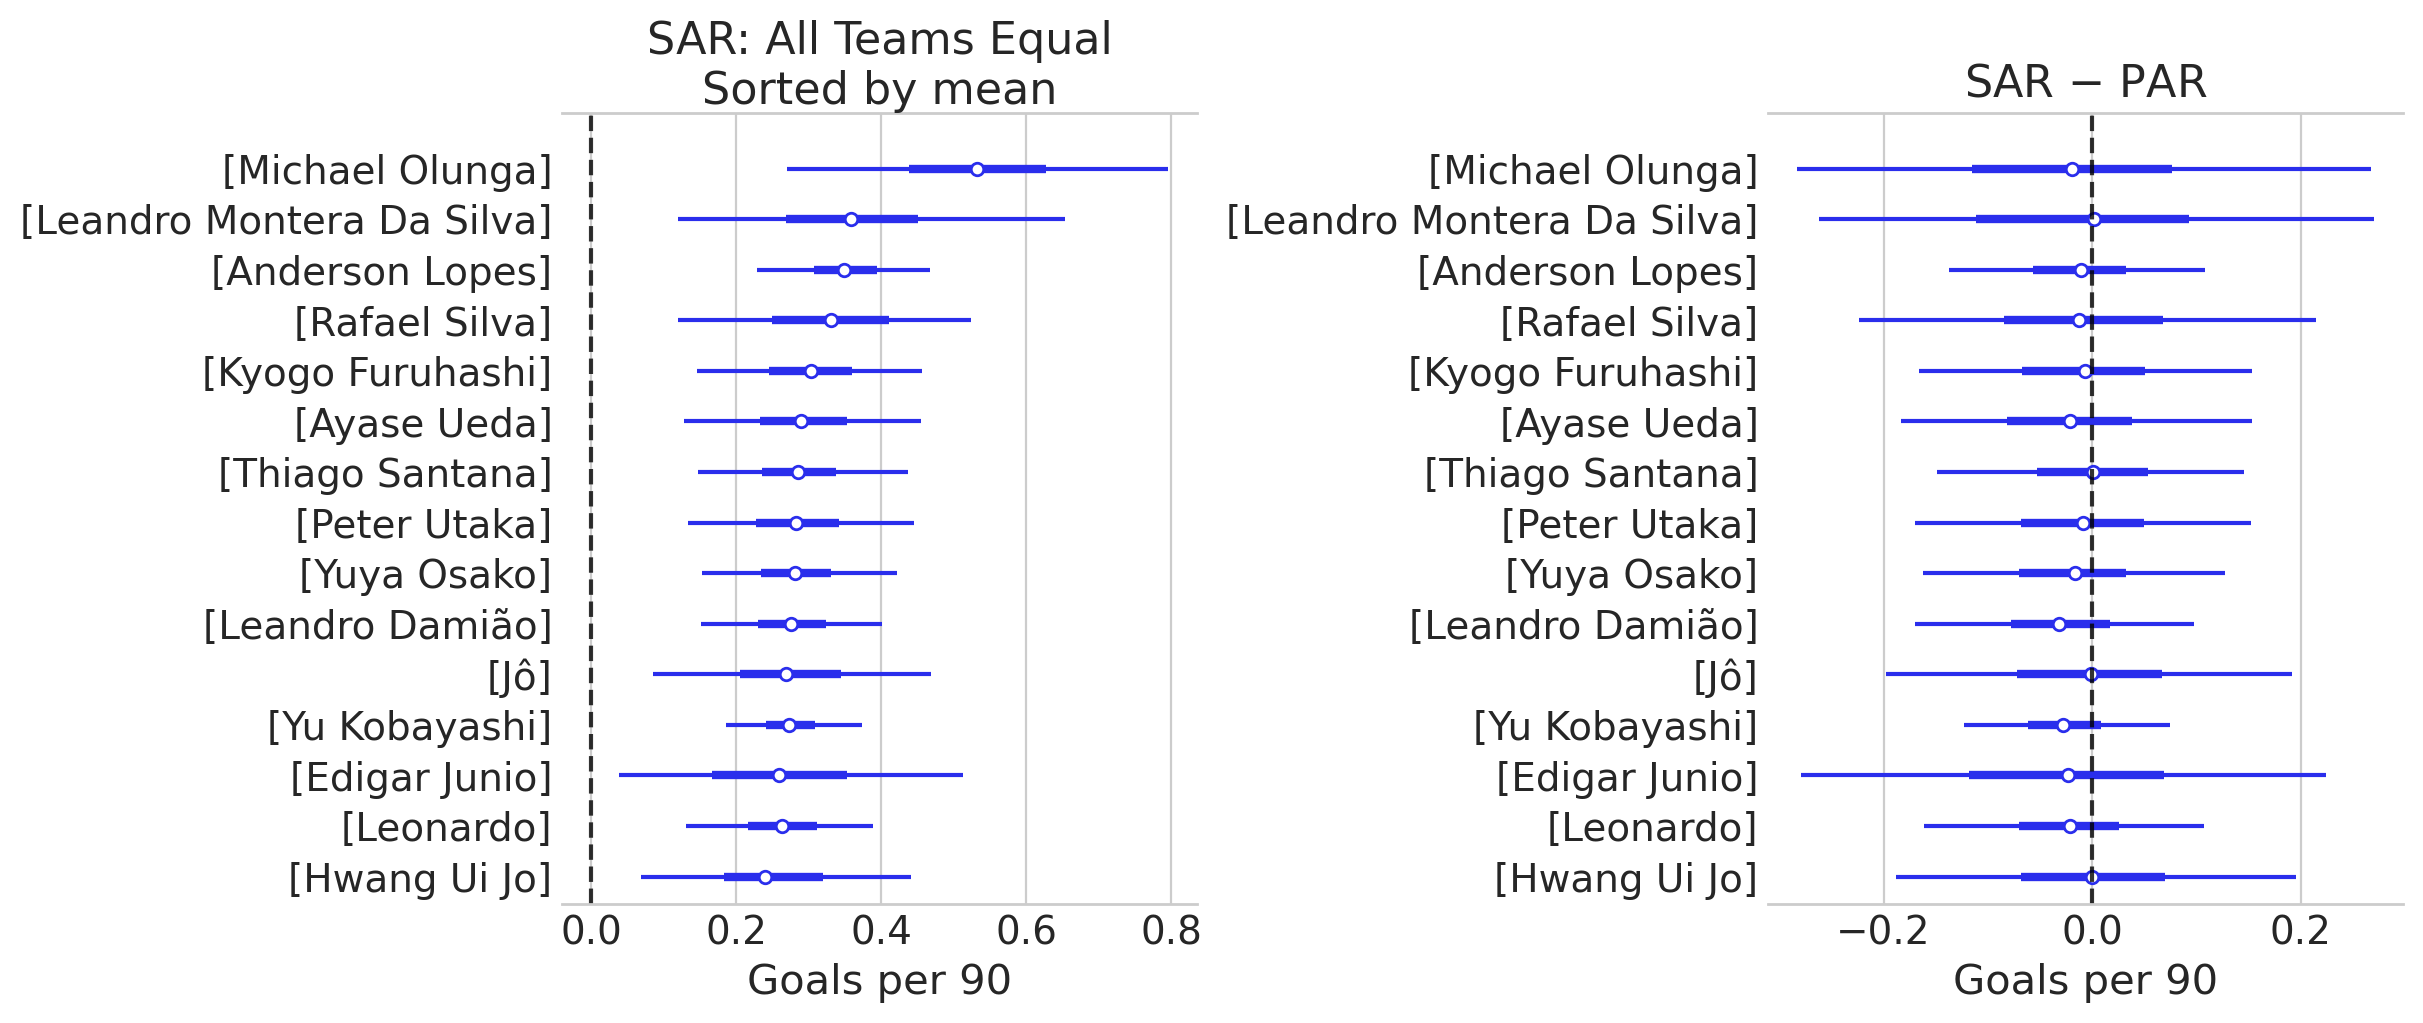

In [481]:
_, (left, right) = plt.subplots(1, 2)

az.plot_forest(sorted_SAR_plot, combined=True, ax=left)
az.plot_forest(sorted_diff_plot, combined=True, ax=right)

left.axvline(c="k", ls="--", alpha=0.8)
left.set(title="SAR: All Teams Equal\nSorted by mean", xlabel="Goals per 90")
right.axvline(c="k", ls="--", alpha=0.8)
right.set(title="SAR $-$ PAR", xlabel="Goals per 90");

In [486]:
selected_SAR = SAR.isel(name_player=sorted_indices)
selected_players = selected_SAR.name_player.values
selected_players = [name for name in selected_players if name in salaries.name_player.values and name != "Andrés Iniesta"]
selected_players = [name for name in selected_players if name in salaries.name_player.values and name != "Andrés Iniesta"]

salary_indices = np.array([salaries.loc[salaries.name_player == name].index.values for name in selected_players if name in salaries.name_player.values]).flatten()
selected_salaries = salaries.iloc[salary_indices,:]
selected_SAR = selected_SAR.sel(name_player=selected_players)

In [487]:
selected_SAR.to_dataframe().to_csv("data/sar_estimates.csv")

Text(0, 0.5, 'Natural logarithm of annual salary')

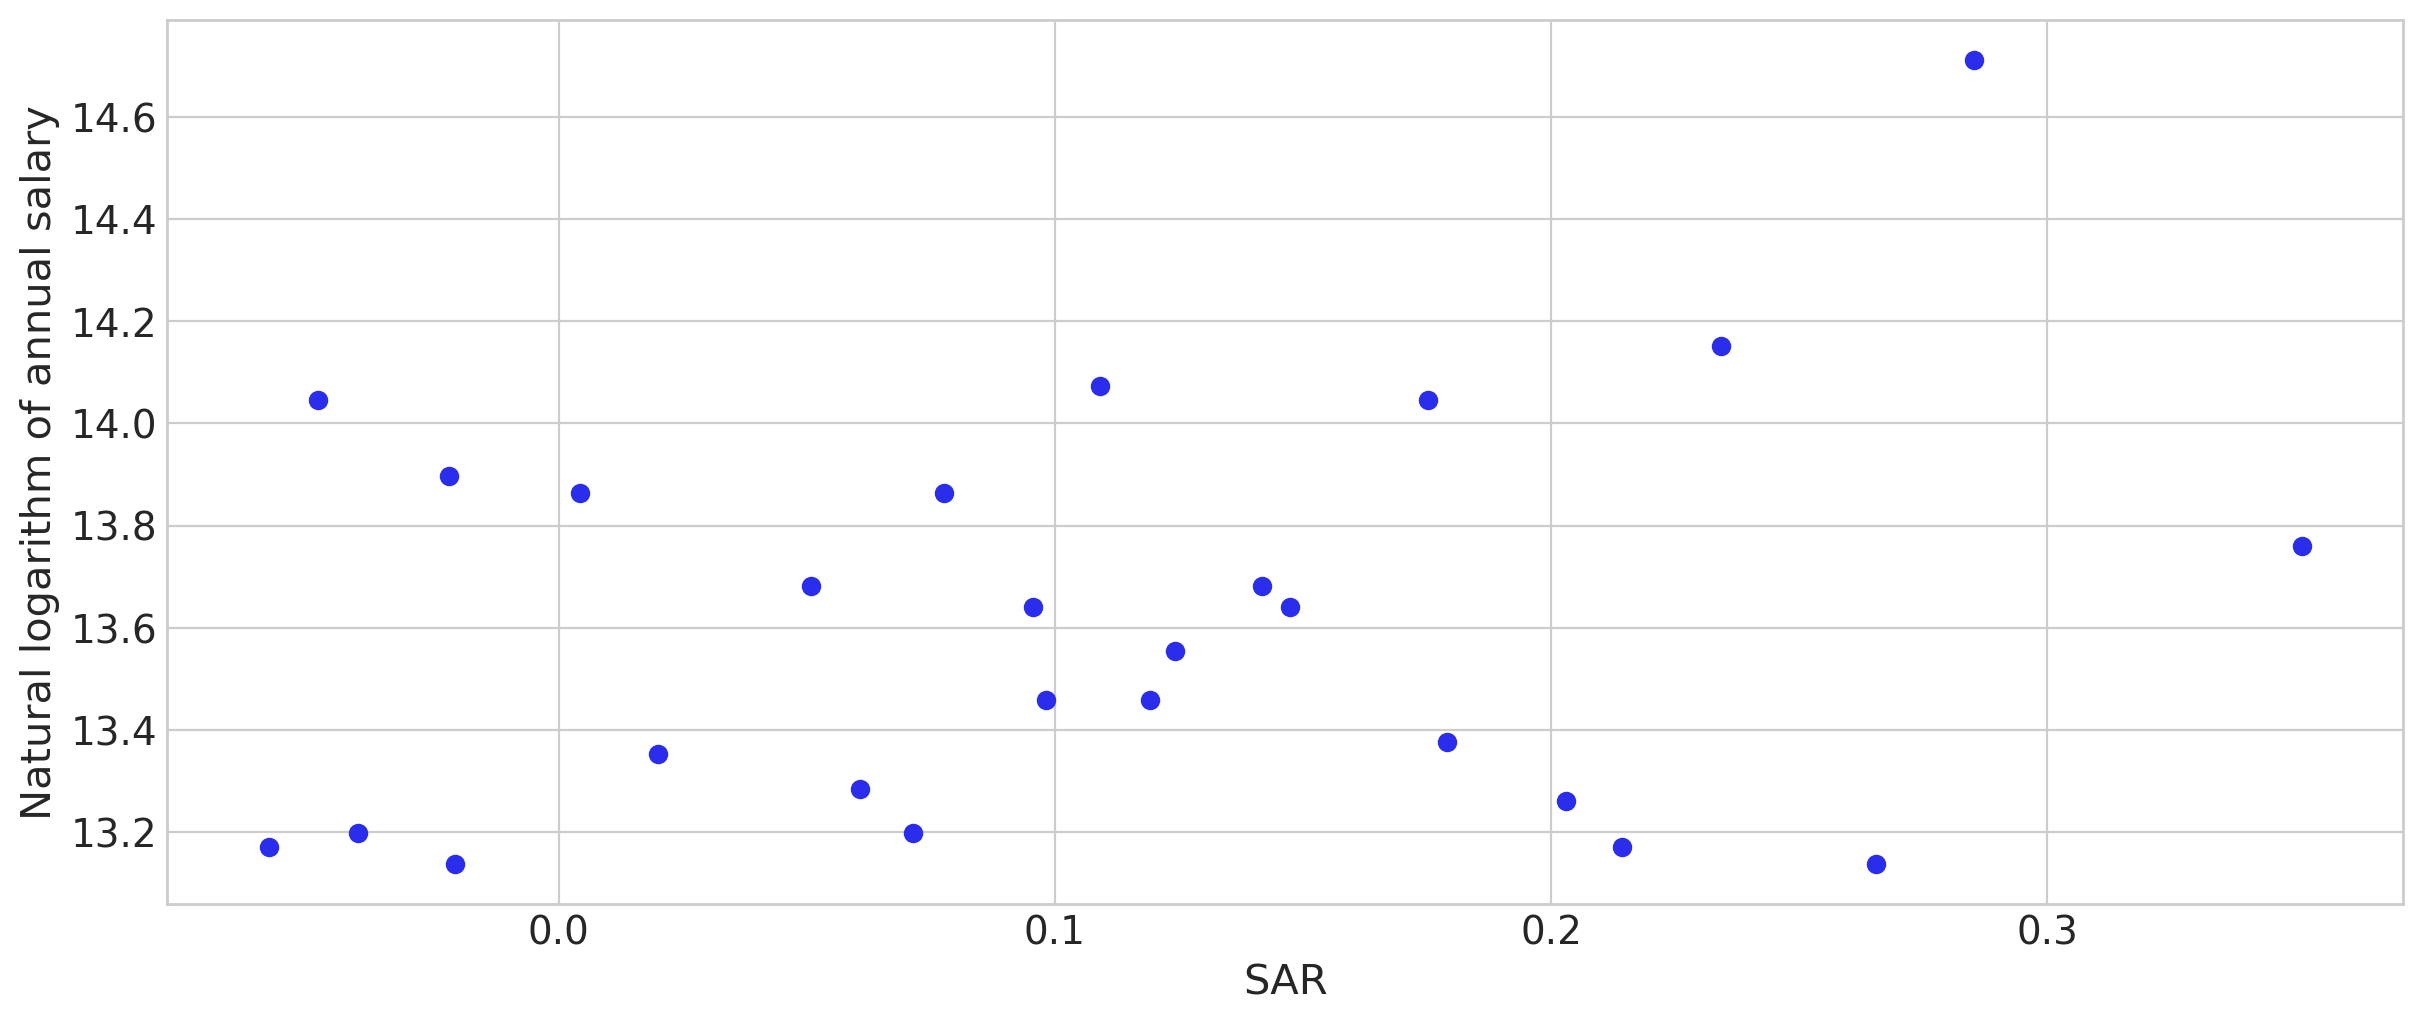

In [488]:
plt.scatter(selected_SAR.mean(["chain", "draw"]).to_numpy(), np.log(selected_salaries.annual_salary.values))
plt.xlabel("SAR")
plt.ylabel("Natural logarithm of annual salary")

In [489]:
selected_SAR.mean(["chain", "draw"]).to_dataframe().join(selected_salaries.set_index("name_player")[["annual_salary"]]).to_csv("data/mean_sar_and_salary.csv")

In [490]:
X_xr = xr.concat([xr.ones_like(selected_SAR), selected_SAR], dim="X").assign_coords(X=[0, 1]).transpose(..., "X")
Y_xr = xr.DataArray(np.log(selected_salaries.annual_salary.values), dims=["name_player"], coords=[selected_players]).expand_dims(chain=selected_SAR.chain, draw=selected_SAR.draw).transpose("chain", "draw", "name_player")

In [491]:
X = X_xr.to_numpy()
Y = np.expand_dims(Y_xr.to_numpy(), axis=-1)
X_tr = X.transpose(0, 1, 3, 2)
m_inv = np.array([np.linalg.inv(m) for m in (X_tr @ X)])
beta_hat = m_inv @ X_tr @ Y

Y_hat = X @ beta_hat
residuals = Y - Y_hat
sigma_squared = np.expand_dims(np.expand_dims(np.sum(residuals.squeeze() ** 2, axis=-1) / (30 - 2), axis=-1), axis=-1)

var_beta = np.multiply(sigma_squared, m_inv)
se_beta = np.sqrt(np.concatenate((np.expand_dims(var_beta[:,:,0,0], axis=-1),
                                  np.expand_dims(var_beta[:,:,1,1], axis=-1)), axis=-1))

In [492]:
se_beta[:,:,1].mean()

0.6112108760751536

In [493]:
betas = xr.DataArray(beta_hat.squeeze(), dims=["chain", "draw", "beta"], coords=[X_xr.chain, X_xr.draw, [0, 1]])
betas.sel(beta=0)

<xarray.DataArray (chain: 4, draw: 1000)> Size: 32kB
array([[13.54017163, 13.62572977, 13.49945384, ..., 13.5510986 ,
        13.48203689, 13.57125784],
       [13.54904017, 13.58465476, 13.55408457, ..., 13.49157852,
        13.53652928, 13.5534555 ],
       [13.50626855, 13.52283236, 13.52126298, ..., 13.48028067,
        13.51424363, 13.54541172],
       [13.52152142, 13.50583945, 13.53263757, ..., 13.49802087,
        13.50240939, 13.54460264]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
    beta     int64 8B 0

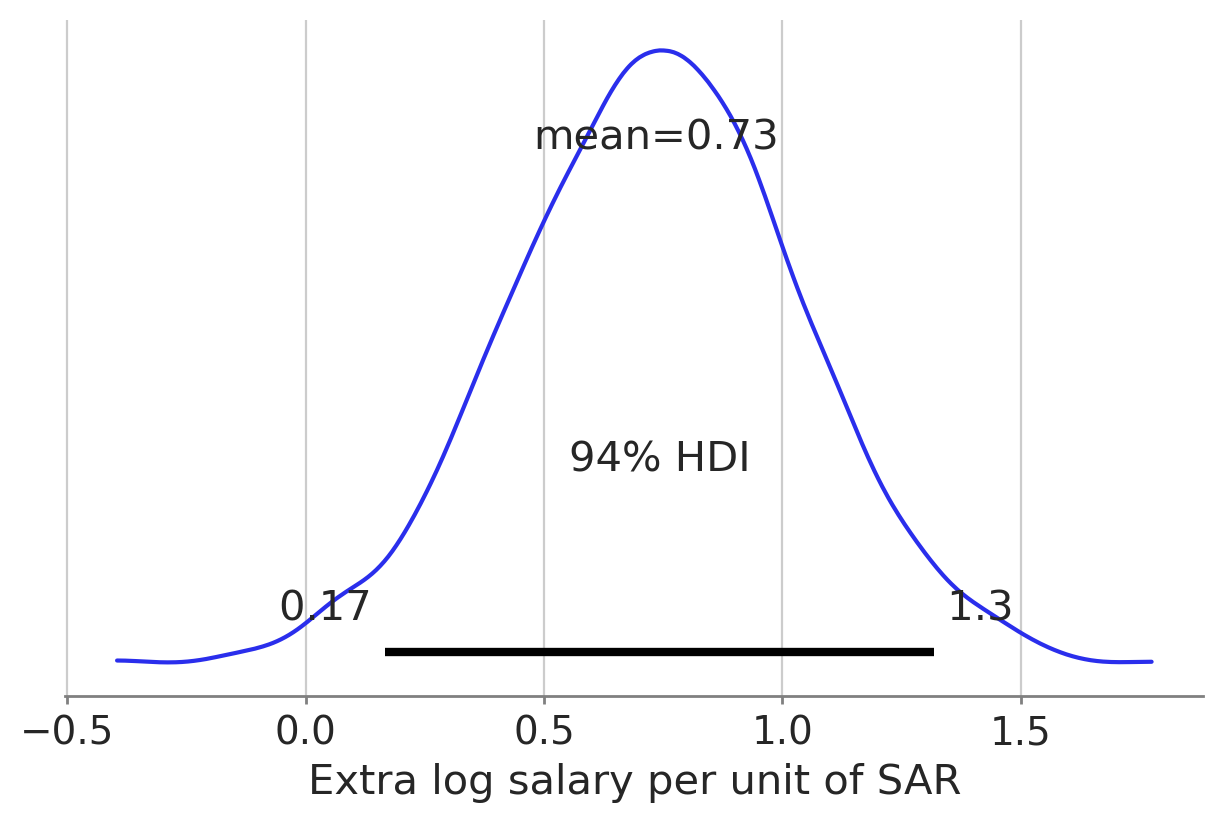

In [494]:
_, ax = plt.subplots(1, 1, figsize=(6, 4))
az.plot_posterior(betas.sel(beta=1), ax=ax)
ax.set(title="", xlabel="Extra log salary per unit of SAR")
plt.savefig('images/log_salary_per_sar_coefficient.png', dpi=100)

In [495]:
betas.sel(beta=1).to_numpy()

array([[ 0.71128643, -0.15498595,  0.96285167, ...,  0.50112177,
         1.04098509,  0.2918523 ],
       [ 0.50878421,  0.26078067,  0.48196702, ...,  1.06492351,
         0.68191612,  0.48602563],
       [ 0.86524134,  0.75124181,  0.84552024, ...,  1.11452616,
         0.88579088,  0.64694499],
       [ 0.78809122,  1.02147391,  0.67504587, ...,  1.02117203,
         0.94408386,  0.53494217]])

Text(0, 0.5, 'Salary')

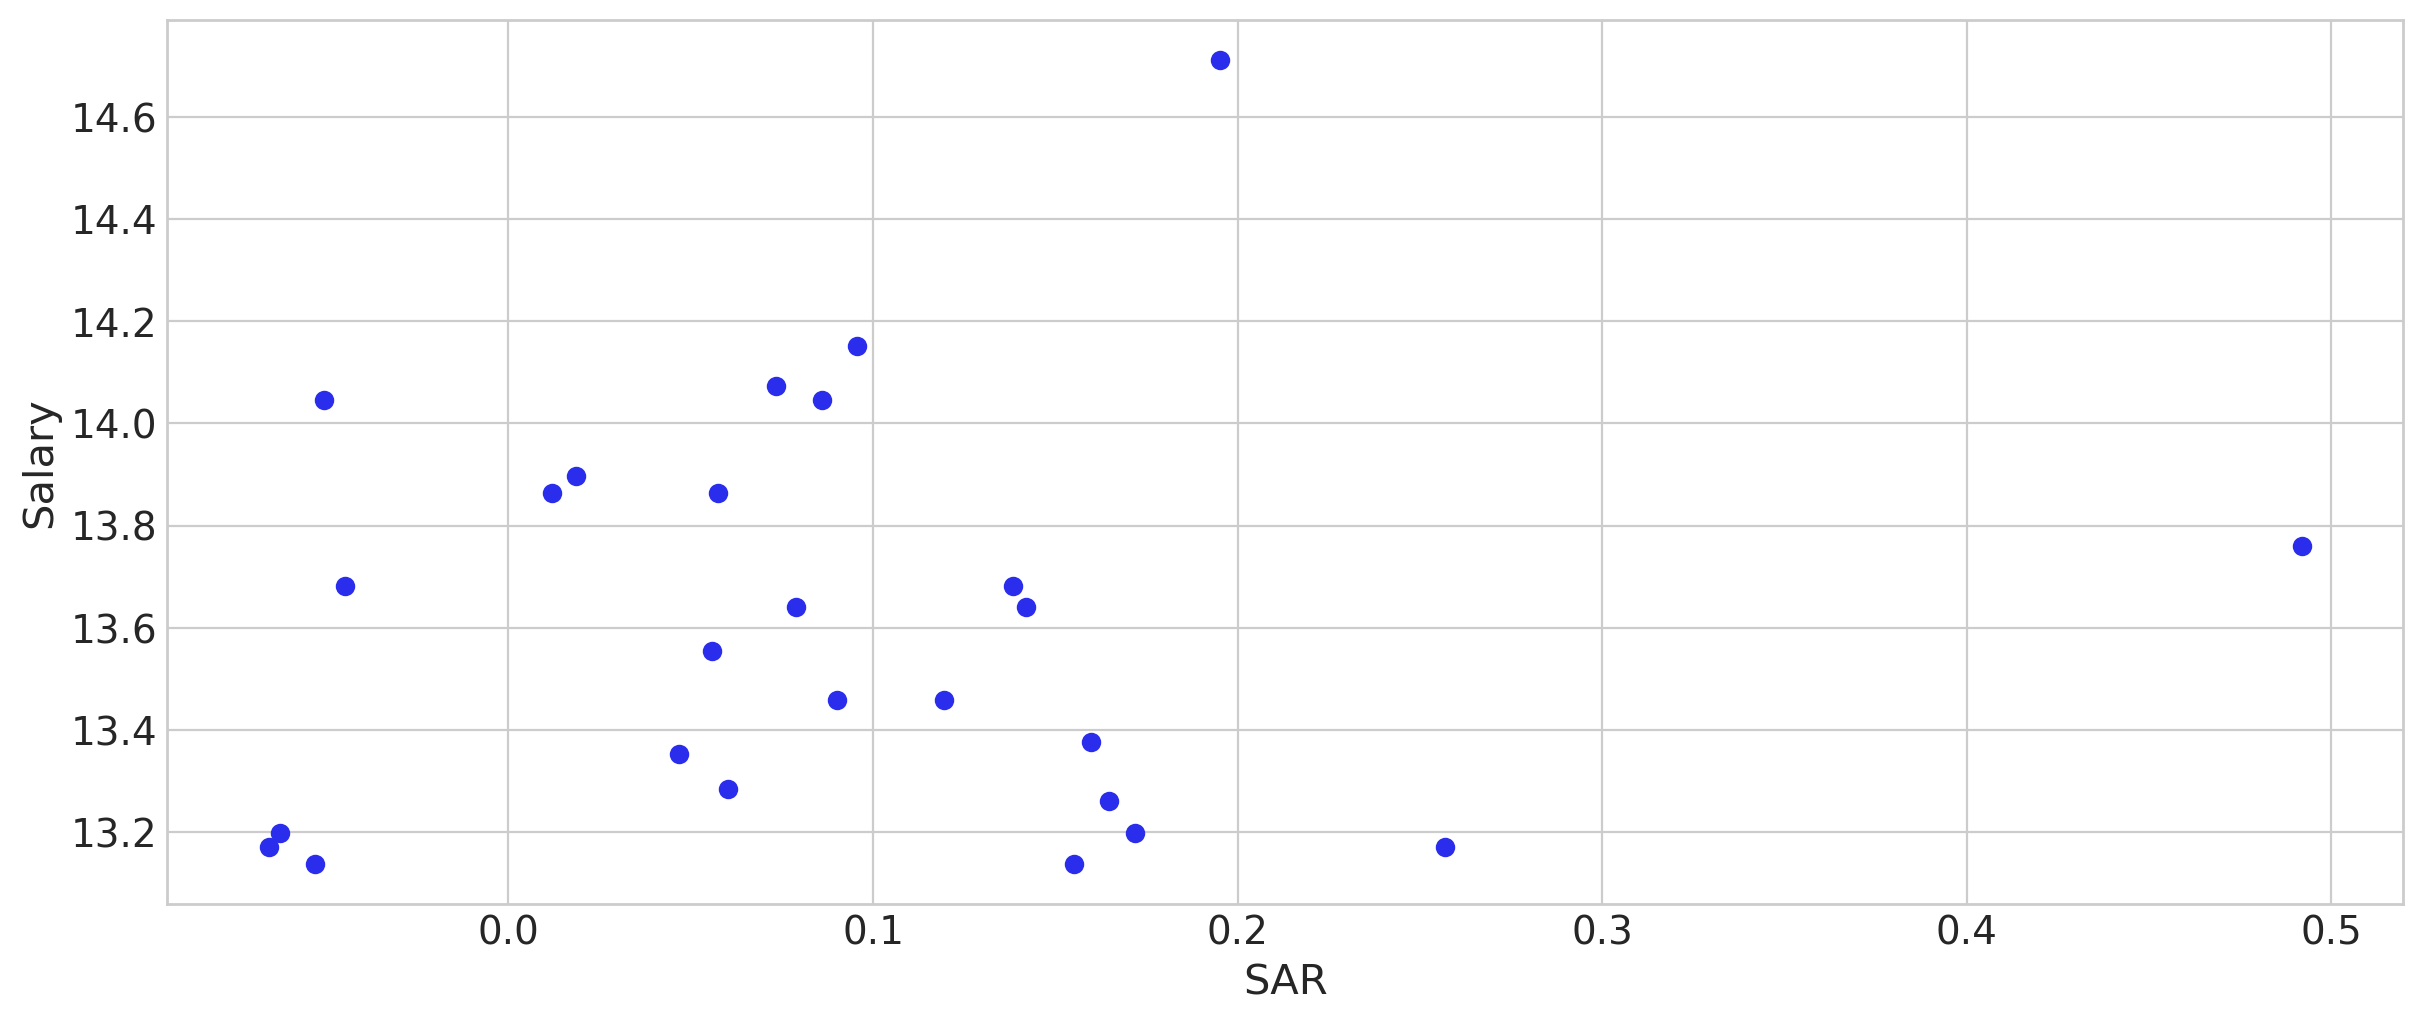

In [496]:
chain = 1
draw = 1
plt.scatter(X_xr.sel(chain=chain, draw=draw, X=1).to_numpy().flatten(), Y_xr.sel(chain=0, draw=0).to_numpy().flatten())
plt.xlabel("SAR")
plt.ylabel("Salary")

Text(0, 0.5, 'SE')

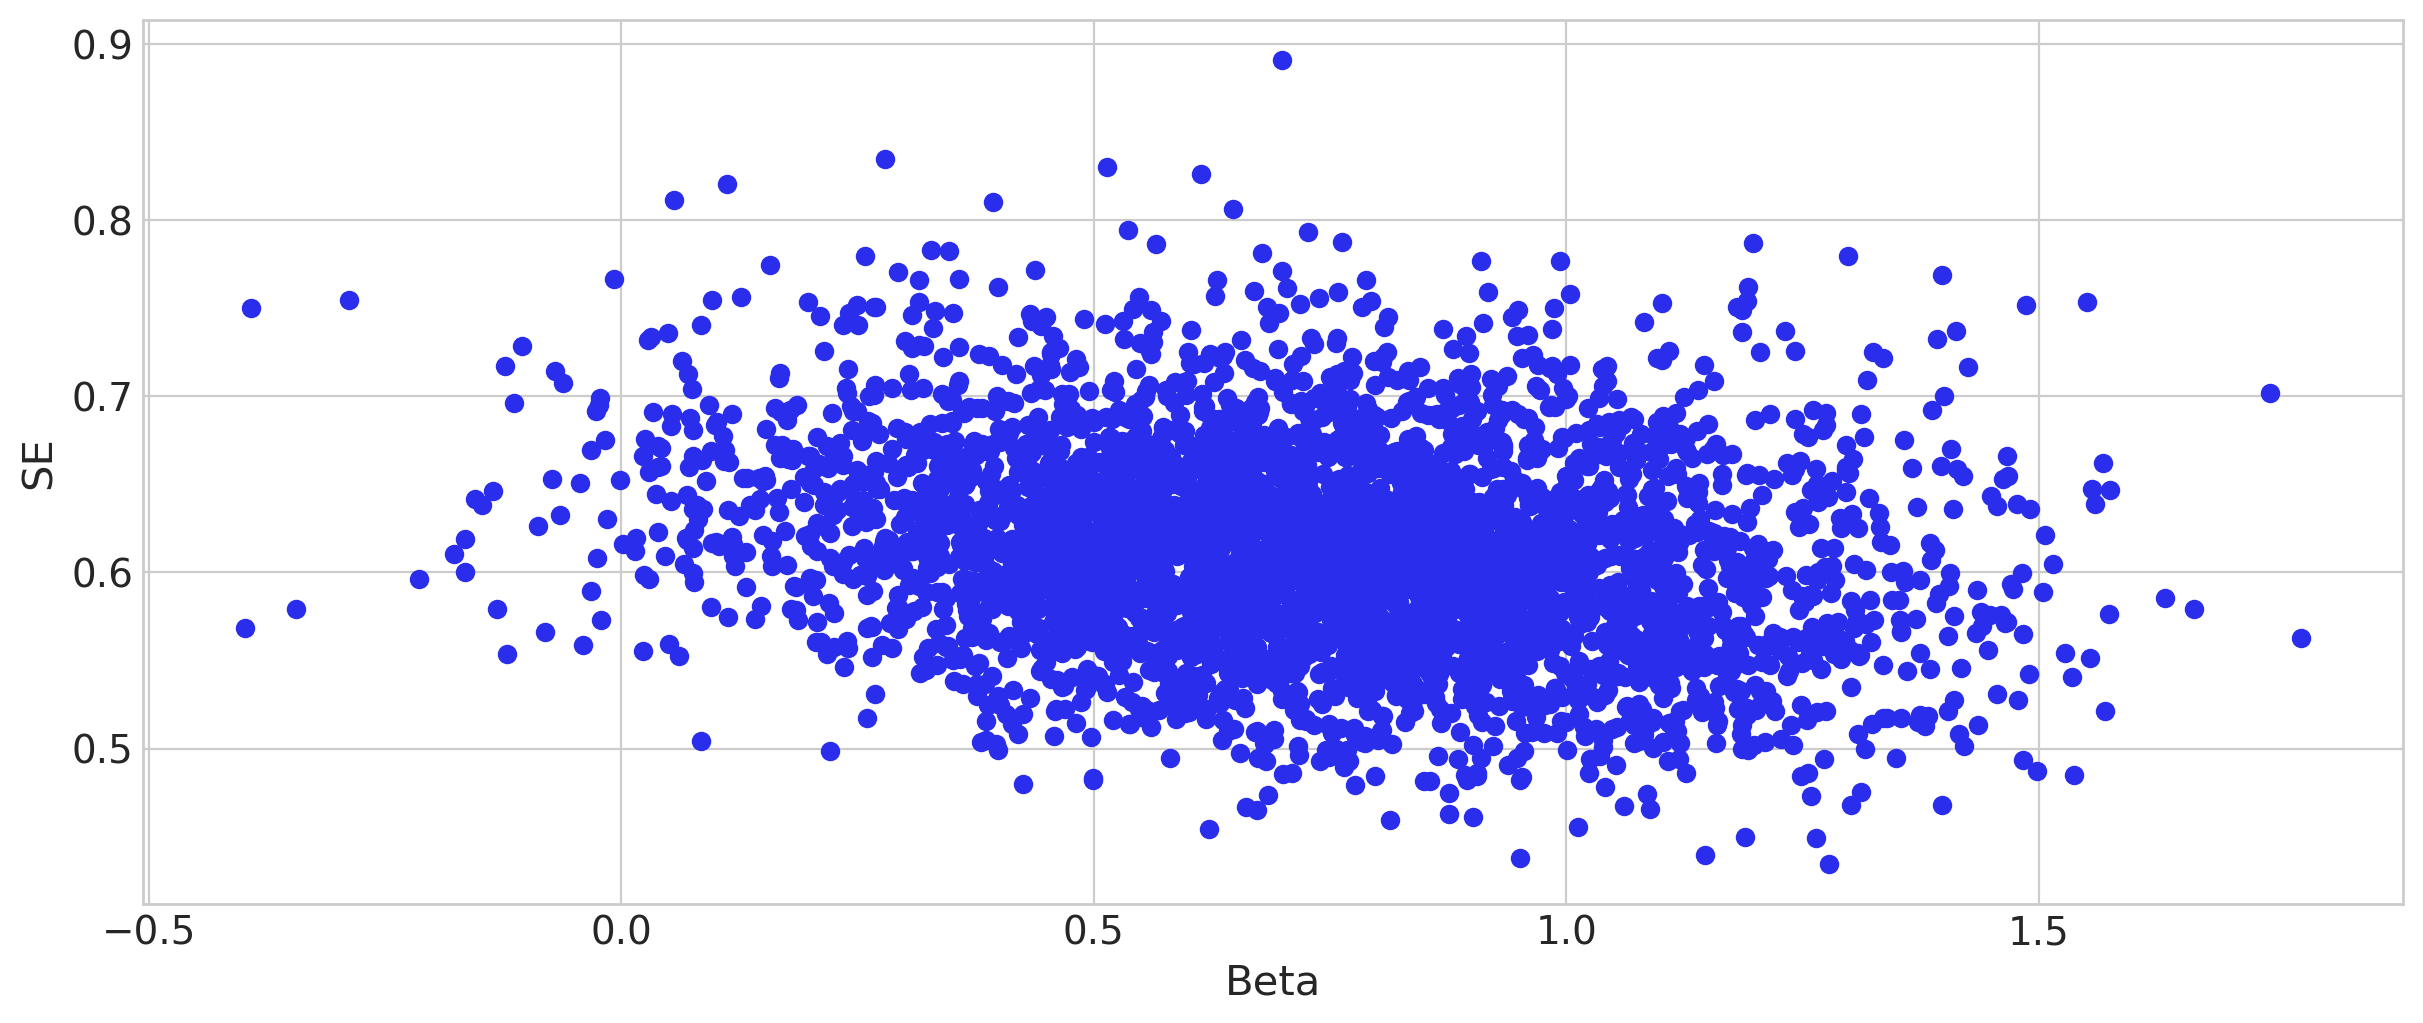

In [497]:
plt.scatter(betas.sel(beta=1).to_numpy().flatten(), se_beta[:,:,1].flatten())
plt.xlabel("Beta")
plt.ylabel("SE")

(array([  3.,   1.,   1.,  10.,   9.,  24.,  48.,  53.,  77., 131., 190.,
        236., 272., 310., 378., 369., 399., 350., 307., 244., 202., 136.,
         91.,  65.,  44.,  29.,  13.,   4.,   2.,   2.]),
 array([-0.39761854, -0.32513761, -0.25265668, -0.18017575, -0.10769482,
        -0.03521388,  0.03726705,  0.10974798,  0.18222891,  0.25470984,
         0.32719077,  0.39967171,  0.47215264,  0.54463357,  0.6171145 ,
         0.68959543,  0.76207636,  0.8345573 ,  0.90703823,  0.97951916,
         1.05200009,  1.12448102,  1.19696195,  1.26944289,  1.34192382,
         1.41440475,  1.48688568,  1.55936661,  1.63184754,  1.70432848,
         1.77680941]),
 <BarContainer object of 30 artists>)

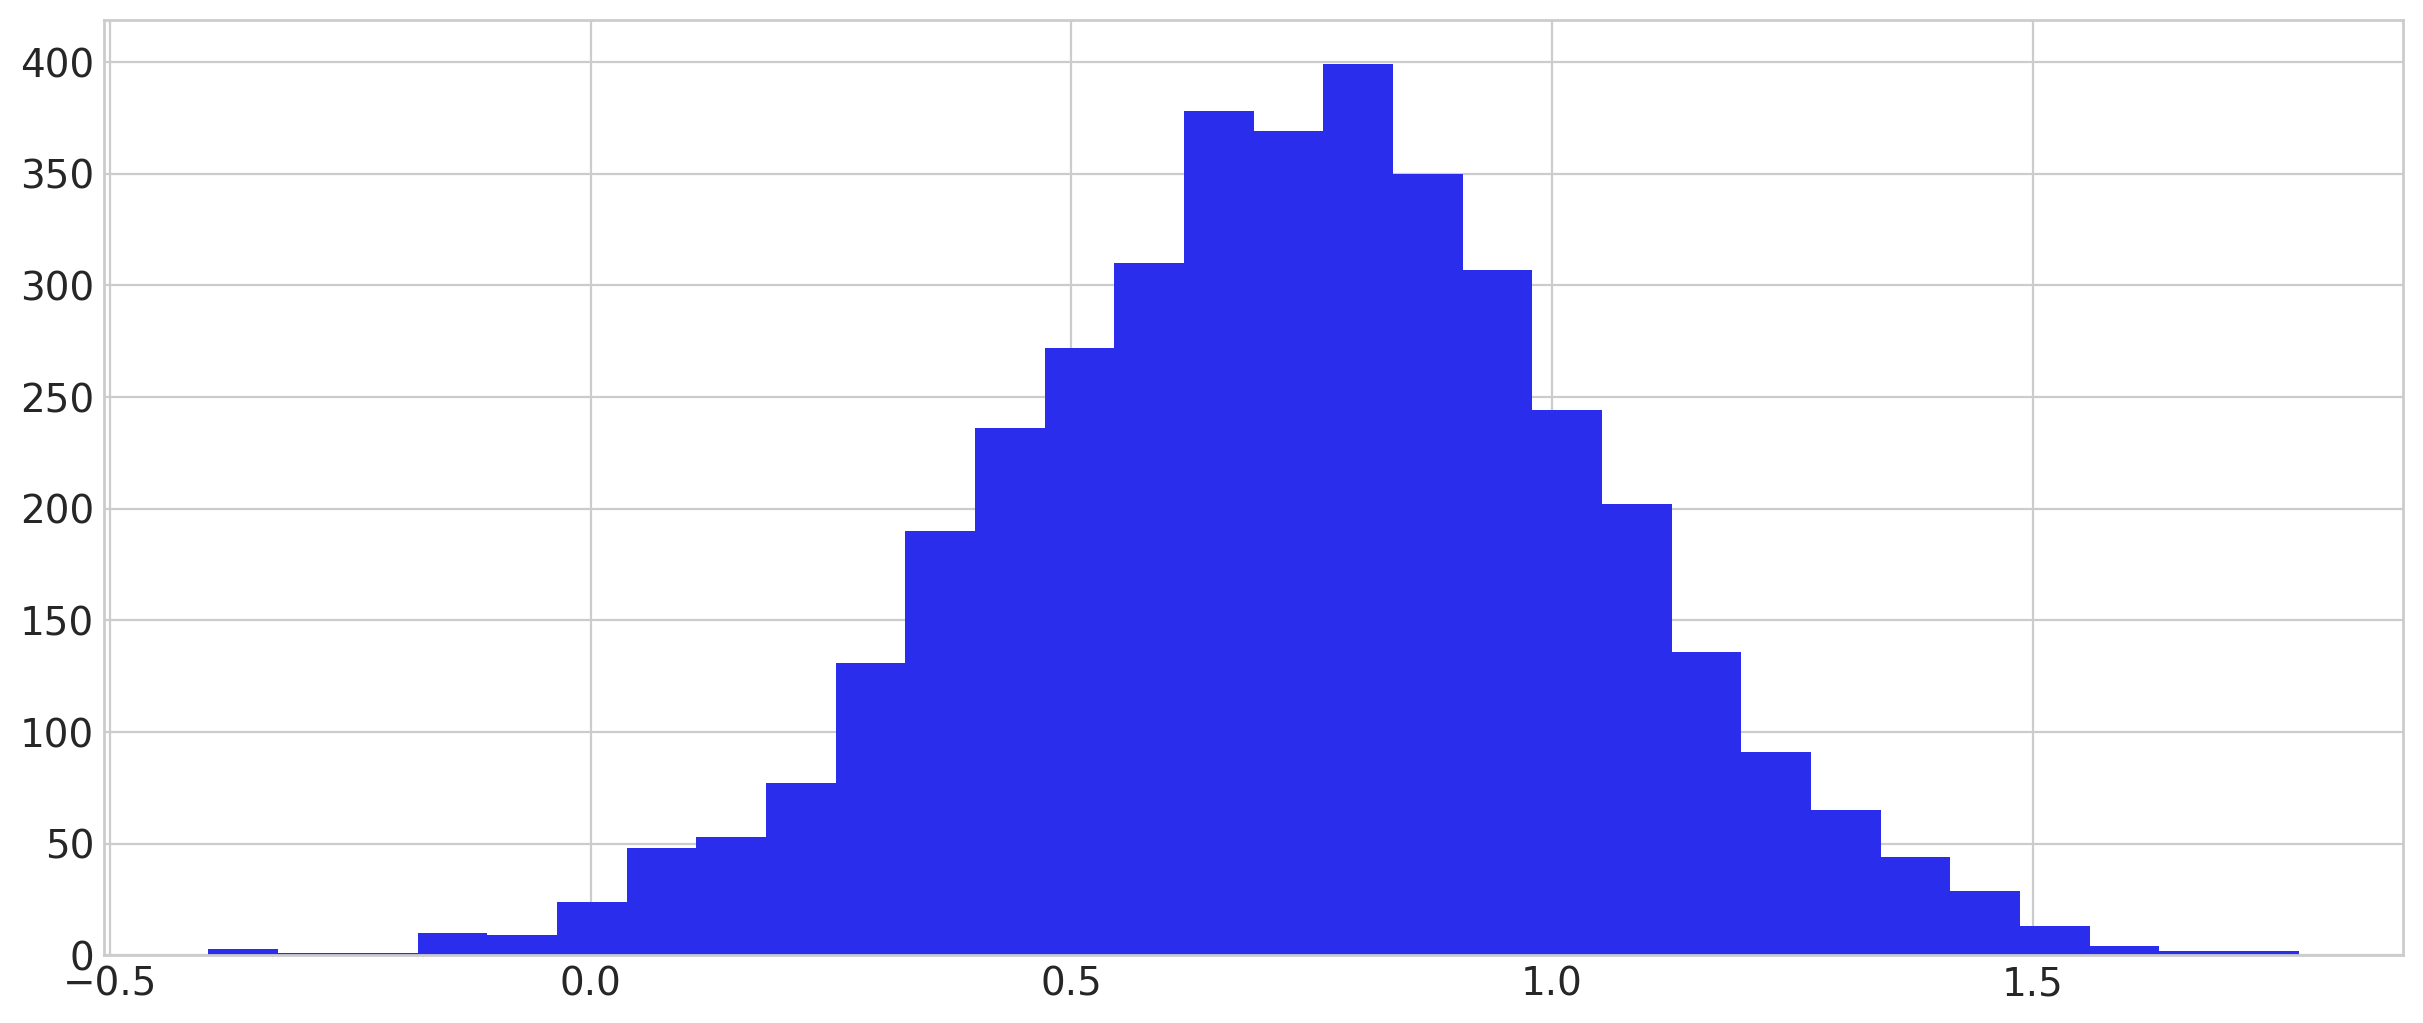

In [498]:
plt.hist(betas.sel(beta=1).to_numpy().flatten(), bins=30)

In [499]:
betas.sel(beta=1).to_numpy().flatten().mean()

0.7343089494183574

In [500]:
az.hdi(betas.sel(beta=1))

<xarray.Dataset> Size: 72B
Dimensions:  (hdi: 2)
Coordinates:
    beta     int64 8B 1
  * hdi      (hdi) <U6 48B 'lower' 'higher'
Data variables:
    x        (hdi) float64 16B 0.1673 1.318

In [501]:
betas.to_dataframe(name="estimate").to_csv("data/beta_estimates.csv")

In [502]:
betas.sel(beta=1).to_numpy().flatten().mean()

0.7343089494183574

In [519]:
np.median(betas.sel(beta=1).to_numpy().flatten())

0.7377547257810215

In [504]:
np.exp(0.73) - 1

1.183654828863502

In [513]:
np.exp(0.73 * 0.1) - 1

0.07573053691470344

In [517]:
np.exp(0.17 * 0.1) - 1

0.017145322325240686

In [518]:
np.exp(1.3 * 0.1) - 1

0.13882838332462177